In [ ]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__.split('+')[0])")+cu118.html


In [ ]:
!pip install torch-geometric

In [58]:
import torch
import torch.nn as nn
from collections import OrderedDict
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')

# define datatype
if torch.cuda.is_available():
    dtype = torch.cuda.FloatTensor
    dtype_long = torch.cuda.LongTensor
else:
    dtype = torch.FloatTensor
    dtype_long = torch.LongTensor

# model formulation
class GNN_LMSC_cell(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, units:int, gcn_type: str,
                    batch_size: int,  # this entry is unnecessary, kept only for backward compatibility
                    width=125, depth=4,):
            super(GNN_LMSC_cell, self).__init__()

            self.in_channels = in_channels
            self.out_channels = out_channels
            self.units = units
            self.gcn_type = gcn_type
            self.batch_size = batch_size  # not needed
            self.depth = depth

            start_dim = units + in_channels
            inside_dim = start_dim
            self.qb =  Quadratic_block(inside_dim, width, depth)

            if gcn_type == 'GCNConv':
                self.gconv1 = GCN_block(inside_dim, inside_dim, layer = 1)
                self.gconv2 = GCN_block(inside_dim, inside_dim, layer = 1)

            if self.depth>0:
                inside_dim = width
            else:
                inside_dim = in_channels

            self.fc_alpha = nn.Linear(inside_dim,units)
            self.fc_beta = nn.Linear(inside_dim,units)

            for m in self.modules():
                if isinstance(m, nn.Linear):
                    torch.nn.init.xavier_uniform_(m.weight)
                    if m.bias is not None:
                        m.bias.data.fill_(0)
                    # m.bias.data.fill_(0)

    def forward(
        self,
        X: torch.FloatTensor,
        edge_index: torch.LongTensor,
        edge_weight: torch.FloatTensor = None,
        H: torch.FloatTensor = None,
        ) -> torch.FloatTensor:

        # Input strain increment X-> [batch, seq_len, in_dim]
        # Hidden state H -> [batch, node_number, hidden_dim]

        h_t = H

        strain_norm = torch.norm(X[:,:,0:6],dim=2)
        # strain_norm = torch.norm(X[:,:,0:9],dim=2)
        x_input = X.clone()
        # x_input[:,:,0:9] = (x_input[:,:,0:9].squeeze(1)/(strain_norm + 1e-15)).unsqueeze(1)
        x_input[:,:,0:6] = (x_input[:,:,0:6].squeeze(1)/(strain_norm + 1e-15)).unsqueeze(1)

        cat_input = torch.cat([x_input.repeat(1,h_t.shape[1],1),h_t], dim = 2)

        # graph embedding
        if self.gcn_type == 'GCNConv':
            G_input1 = self.gconv1(cat_input, edge_index)
            G_input1 = F.relu(G_input1)
            G_input2 = self.gconv2(cat_input, edge_index)
            G_input2 = F.relu(G_input2)
        else:
            G_input1 = cat_input
            G_input2 = cat_input

        G_input1 = torch.tanh(self.qb(G_input1))
        G_input2 = torch.tanh(self.qb(G_input2))

        alpha = torch.exp(self.fc_alpha(G_input1))
        beta  = torch.tanh(self.fc_beta(G_input2))

        exp_f =  torch.exp(- alpha * strain_norm.unsqueeze(2).repeat(1,1,self.units))
        h = exp_f * (h_t  - beta) + beta

        return h.squeeze(1)


class GNN_LMSC_Model(nn.Module):
    def __init__(self, args, output_depth=3):
        super(GNN_LMSC_Model, self).__init__()
        self.hidden_dim = args.hidden_dim
        self.seq_len = args.seq_len
        self.output_dim = args.node_output_dim
        self.batch_size = args.batch_size
        self.node_num = args.num_nodes
        self.input_dim = args.node_input_dim
        self.lmsc = GNN_LMSC_cell(args.node_input_dim, args.node_output_dim,
                                   units= args.hidden_dim, gcn_type=args.GCN_type, batch_size=args.batch_size)

        if args.out_type == 'FCNN':
            self.decoder = FCNN(args.layers, nn.ReLU)
        else:
            output_depth = args.out_depth
            self.decoder = Quadratic_block(args.hidden_dim, args.node_output_dim, output_depth)

    def forward(self, data):
        '''
        -Data structure
            1. x: input strain increment
            2. edge_index: grain connections in the format of adjacency list
            3. init_ori: initial grain orientations [grain_number, 3]
        '''
        x, edge_index = data.x.type(dtype), data.edge_index
        edge_index = edge_index.to(device)

        # preprocessing for batch training
        # Input strain increment X-> [batch, seq_len, feature_dim]
        x = x.view(-1,self.seq_len, self.input_dim)
        edge_index = edge_index[:,0:edge_index.size(1)//self.batch_size]

        # Hidden state H -> [batch, node_number, hidden_dim]
        # h0 = torch.zeros(x.size(0), self.node_num, self.hidden_dim)\
        #     .requires_grad_().to(device)
        h0 = torch.zeros(
            x.size(0), self.node_num, self.hidden_dim,
            device=device
        )
        # hidden_out = torch.zeros(x.size(0), self.node_num, x.size(1),\
        #                           self.hidden_dim).requires_grad_().to(device)
        hidden_out = torch.zeros(
            x.size(0), self.node_num, x.size(1), self.hidden_dim,
            device=device
        )

        # Assign initial orientation to hidden state
        # h0[:,:,0:3] = data.init_ori.view(-1,self.node_num,3).to(device)
        h0[:,:,0:4] = data.init_ori.view(-1,self.node_num,4).to(device)
        h_last = h0.clone()

        # sequential prediciton
        for i in range(x.size(1)):
            x_input = x[:,i,:].unsqueeze(1).clone()
            h_last = self.lmsc(x_input, edge_index, H = h_last)
            h_last = h_last.clone()
            hidden_out[:,:,i,:] = h_last.squeeze(1)

        # decode the hidden state to Output feature matrix
        # [batch, node_number, hidden_dim] -> [batch, node_number, out_dim]
        hidden_out = self.decoder(hidden_out)

        # output normalised quaternion
        # q_raw = hidden_out[..., 0:4]
        # q_unit = F.normalize(q_raw, p=2, dim=-1, eps=1e-8)
        # hidden_out = torch.cat([q_unit, hidden_out[..., 4:]], dim=-1)

        return hidden_out



class Quadratic_block(nn.Module):
    def __init__(self, input_dim, out_dim, depth):
        super(Quadratic_block, self,).__init__()
        self.modlist1 = nn.ModuleList()
        self.modlist2 = nn.ModuleList()
        self.depth = depth
        for i in range(depth):
            if i == depth-1:
                self.modlist1.append(torch.nn.Linear(input_dim, out_dim, bias=False))
                self.modlist2.append(torch.nn.Linear(input_dim, out_dim, bias=False))
            else:
                self.modlist1.append(torch.nn.Linear(input_dim, input_dim, bias=False))
                self.modlist2.append(torch.nn.Linear(input_dim, input_dim, bias=False))

    def forward(self, x):
        i = 0
        for m in self.modlist1:
            x1 = m(x)
            m2 = self.modlist2[i]
            x2 = m2(x)
            i += 1
            if i < self.depth:
                x1 = torch.tanh(x1)
                x2 = torch.tanh(x2)
            x = x1 * x2
        return x


class GCN_block(nn.Module):
    def __init__(self, in_channels, out_channels, layer,\
                  improved=False, cached=False, add_self_loops=True):
        super(GCN_block, self,).__init__()
        self.modlist = nn.ModuleList()
        self.layer = layer
        for i in range(layer):
            if i == 0:
                self.modlist.append(GCNConv(in_channels, out_channels,\
                                             improved, cached, add_self_loops))
            else:
                self.modlist.append(GCNConv(out_channels, out_channels,\
                                             improved, cached, add_self_loops))

    def forward(self, x, edge_index):
        i = 0
        for m in self.modlist:
            x = m(x, edge_index)
            i += 1
            if i < self.layer:
                x = torch.relu(x)
        return x


class FCNN(torch.nn.Module):
    def __init__(self, layers, activation):
        super(FCNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1
        # set up layer order dict
        self.activation = activation

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

C:\Users\admin\AppData\Local\Temp\ipykernel_16504\3771504348.py:8: UserWarning: Failed to initialize NumPy: DLL load failed while importing _multiarray_umath: The specified module could not be found. (Triggered internally at ..\torch\csrc\utils\tensor_numpy.cpp:77.)
  device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')


In [59]:
import numpy as np
# import h5py

# h5_data = h5py.File('demo_dataset_PN8_sq100.hdf5')
# all_data = h5_data['data'][:]
# print(all_data.shape)
# print(all_data[0][1][1][0:3])

""" features are: quaternion (0-3), Fp (4-12), strain (13-21), stress (22-30), RVE strain average (31-39)"""
all_data_raw = np.load("simulation_grain_data/grain_feature_tensor.npy")
all_data = np.load("simulation_grain_data/grain_feature_tensor.npy")
print(all_data.shape)

strain_path = all_data[0]
init_ori = strain_path[:, 0, 0:4]

for i in range(22, 31):
    stress_component = all_data[:, :, :, i]
    min_ = stress_component.min()
    max_ = stress_component.max()
    all_data[:, :, :, i] = 2 * ((stress_component - min_) / (max_ - min_ + 1e-8)) - 1
    # all_data[:, :, :, i] = (stress_component - min_) / (max_ - min_ + 1e-8)

print(all_data.shape)

# rve_increments = strain_path[50, :, 31:40]   # grain 0 used, RVE increments are identical for all grains in a strain path
# print(rve_increments)
# strain_incs = rve_increments*100    # Output multiplied by 100, follows the paper.

# print(strain_incs.shape)

(6, 100, 13, 40)
(6, 100, 13, 40)


In [60]:
import numpy as np
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def nx_to_edge_index(G): # convert networkx graph to edge tensor
    # Ensure nodes are labeled 0..N-1
    G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    # Get edge list
    edges = list(G.edges())

    # Make edges bidirectional
    row = []
    col = []
    for i, j in edges:
        row += [i, j]
        col += [j, i]

    edge_index = torch.tensor([row, col], dtype=torch.long)
    return edge_index

def neighbors_txt_to_nx(txt_path): # convert connectivity_list_RVE to networkx graph
    G = nx.Graph()
    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("GrainID") or line.startswith("-"):
                continue
            if ":" not in line:
                continue

            left, right = line.split(":", 1)
            src = int(left.strip())
            G.add_node(src)

            right = right.strip()
            if right:
                nbrs = [int(x.strip()) for x in right.split(",") if x.strip()]
                for dst in nbrs:
                    if src != dst:
                        G.add_edge(src, dst)
    return G

G = neighbors_txt_to_nx("simulation_grain_data/connectivity_list_RVE.txt")
edge_index_tensor = nx_to_edge_index(G)

In [4]:
def normalize_stress(stress, sigma_min, sigma_max):
    return (2 * (stress - sigma_min) / (sigma_max - sigma_min)) - 1

def denormalize_stress(stress_norm, sigma_min, sigma_max):
    return (stress_norm + 1) * (sigma_max - sigma_min) / 2 + sigma_min

def tensor9_to_voigt6(t9):
    """
    Converts (..., 9) tensor -> (..., 6)
    """
    return np.stack([
        t9[..., 0],  # 11
        t9[..., 4],  # 22
        t9[..., 8],  # 33
        t9[..., 1],  # 12
        t9[..., 2],  # 13
        t9[..., 5],  # 23
    ], axis=-1)

def create_data_object(strain_path): # shape (node_num: grains, seq_len: strain increments, feature_dim: variables)
    """
        Inputs
    """
    init_ori = strain_path[:, 0, 0:4]    
    # init_ori = strain_path[:100, 0, 0:3]     # initial orientation of all 100 grains, excluded 101th grain for homogenized RVE
    # init_ori = np.deg2rad(init_ori)    # convert to radians
    init_ori = torch.tensor(init_ori, dtype=torch.float32)

    rve_increments = strain_path[0, :, 31:40]   # grain 0 used, RVE increments are identical for all grains in a strain path
    rve_increments = tensor9_to_voigt6(rve_increments)  # convert 9 component to 6 component, (13,9) -> (13,6)
    strain_incs = rve_increments*100    # Output multiplied by 100, follows the paper.
    strain_incs = torch.tensor(strain_incs, dtype=torch.float32)

    # rve_acc_strain = strain_path[100, :, 9:15]    # accumulated strain of homogenized RVE. Scaled by 100, following the paper.
    # strain_incs = np.zeros((100, 6), dtype=np.float32)
    # strain_incs[1:] = np.diff(rve_acc_strain, axis=0)    # calculating strain increment, from accumulated strain. First element remains as 0.
    # strain_incs *= 100    # Output multiplied by 100, follows the paper.
    # strain_incs = torch.tensor(strain_incs, dtype=torch.float32)

    edge_index = edge_index_tensor

    data = Data(
        x=strain_incs,       # shape (seq_len,6) = (13,6)
        edge_index=edge_index,
        init_ori=init_ori,    # shape (100,4)
        num_nodes=100
    )
    return data


# def create_ground_truth(strain_path, sigma_min, sigma_max):
def create_ground_truth(strain_path):
    """
    Returns normalized ground truth
    """
    orientation = np.copy(strain_path[:, :, 0:4])        # (100, 13, 4)
    stress = np.copy(strain_path[:, :, 22:31])      # (100, 13, 9)
    stress = tensor9_to_voigt6(stress)              # convert 9 component to 6 component, (100, 13, 6)

    y = np.concatenate([orientation, stress], axis=-1)        # (100, 13, 10)
    return torch.tensor(y, dtype=torch.float32)
    # y = np.copy(strain_path[:100, :, :])        # (100, 100, 15), omit 101th grain (RVE homogenized)

    # y[:, :, 0:3] = np.deg2rad(y[:, :, 0:3]) # convert orientation to radians

    # # normalize stress channels only (3:9)
    # y_stress = y[:, :, 3:9]
    # y[:, :, 3:9] = normalize_stress(y_stress, sigma_min, sigma_max)

    # y = torch.tensor(y, dtype=torch.float32)
    # return y

In [116]:
import torch
from torch.utils.data import Dataset
from torch_geometric.loader import DataLoader

train_data = all_data[:4]   # first 4 paths
test_data  = all_data[4:]   # last 2 paths


class StrainPathDataset(Dataset):
    # def __init__(self, data, sigma_min, sigma_max):
    def __init__(self, data):
        self.data = data    # (num_paths, 100, 13, 40)
        # self.sigma_min = sigma_min
        # self.sigma_max = sigma_max

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        strain_path = self.data[idx]  # (100, 13, 40)

        data = create_data_object(strain_path)
        y = create_ground_truth(strain_path)
        # y = create_ground_truth(strain_path, self.sigma_min, self.sigma_max)

        return data, y

# train_dataset = StrainPathDataset(train_data, sigma_min, sigma_max)
# test_dataset  = StrainPathDataset(test_data,  sigma_min, sigma_max)
train_dataset = StrainPathDataset(train_data)
test_dataset  = StrainPathDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False)

Define model

In [117]:
from argparse import Namespace

# args = Namespace(
#     hidden_dim=64,
#     seq_len=100,
#     node_output_dim=15,
#     # batch_size=2,
#     batch_size=1,
#     num_nodes=100,
#     node_input_dim=6,
#     GCN_type='GCNConv',
#     out_type='Quadratic',   # NOT 'FCNN'
#     out_depth=3,
#     layers=None             # unused since out_type != 'FCNN'
# )
args = Namespace(
    hidden_dim=64,
    # hidden_dim = 250,
    seq_len=13,
    node_output_dim=10,     # (4 orientation + 6 stress)
    # batch_size=2,
    batch_size=1,
    num_nodes=100,
    node_input_dim=6,       # (6 stress components per strain increment)
    GCN_type='GCNConv',
    out_type='Quadratic',   # NOT 'FCNN'
    out_depth=3,
    layers=None             # unused since out_type != 'FCNN'
)

model = GNN_LMSC_Model(args)
model = model.to(device)

Quaternion misorientation calculation

In [118]:
def quaternion_misorientation_angle(q_pred, q_true, eps=1e-8):
    """
    Returns misorientation angle theta in radians for unit quaternions.

    q_pred, q_true: (..., 4)
    """
    # Normalize to be safe (predictions often drift off unit norm)
    q_pred = q_pred / (q_pred.norm(dim=-1, keepdim=True) + eps)
    q_true = q_true / (q_true.norm(dim=-1, keepdim=True) + eps)

    # dot in [-1, 1]
    dot = (q_pred * q_true).sum(dim=-1)

    # handle double cover: q and -q are same rotation
    dot = dot.abs()

    # numerical safety
    dot = dot.clamp(-1.0 + 1e-7, 1.0 - 1e-7)

    # theta in [0, pi]
    theta = 2.0 * torch.acos(dot)
    return theta

In [119]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiTaskMSELoss(nn.Module):
    def __init__(self, ori_weight=1.0, stress_weight=1.0):
        super().__init__()
        self.ori_weight = ori_weight
        self.stress_weight = stress_weight

    def forward(self, y_pred, y_true):
        # orientations
        q_pred = y_pred[..., 0:4]
        q_true = y_true[..., 0:4]        

        theta = quaternion_misorientation_angle(q_pred, q_true)  # radians
        ori_loss = (theta ** 2).mean()  # "MSE" of misorientation angle

        # Stress MSE
        stress_mse     = F.mse_loss(y_pred[..., 4:10],  y_true[..., 4:10])
        # stress_mse     = F.mse_loss(y_pred[..., 3:9],  y_true[..., 3:9])

        # Weighted total loss (scalar, used for backprop)
        total_loss = (
            self.ori_weight        * ori_loss +
            self.stress_weight     * stress_mse
        )

        # Return both total and components
        return total_loss, {
            "ori_mse": ori_loss,
            "stress_mse": stress_mse,
        }

In [49]:
# For plotting later
train_history = {
    "total": [],
    "ori": [],
    "stress": [],
}

In [50]:
import os

model.train()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 25000

criterion = MultiTaskMSELoss(
    ori_weight=1.0,
    stress_weight=1.0,
)

# checkpoint settings
save_every = 10
save_dir = "/content/checkpoints"
os.makedirs(save_dir, exist_ok=True)
checkpoint_path = os.path.join(save_dir, "last_checkpoint.pt")

for epoch in range(num_epochs):
    model.train()

    running_total = 0.0
    running_ori = 0.0
    running_stress = 0.0
    n_samples = 0  # or use len(train_loader) if you prefer avg per batch

    for data, y_true in train_loader:
        data = data.to(device)
        y_true = y_true.to(device)

        optimizer.zero_grad()

        y_pred = model(data)

        # use the new criterion
        loss, loss_dict = criterion(y_pred, y_true)

        loss.backward()
        optimizer.step()

        batch_size = data.size(0)
        running_total      += loss.item() * batch_size
        running_ori        += loss_dict["ori_mse"].item() * batch_size
        running_stress     += loss_dict["stress_mse"].item() * batch_size
        n_samples          += batch_size

    # Mean losses over the epoch
    epoch_total      = running_total / n_samples
    epoch_ori        = running_ori / n_samples
    epoch_stress     = running_stress / n_samples

    train_history["total"].append(epoch_total)
    train_history["ori"].append(epoch_ori)
    train_history["stress"].append(epoch_stress)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Total: {epoch_total:.6e} | "
        f"Ori: {epoch_ori:.6e} | "
        f"Stress: {epoch_stress:.6e} | "
    )

    # Save every 10 epochs (and also on the final epoch)
    if (epoch + 1) % save_every == 0 or (epoch + 1) == num_epochs:
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss_total": epoch_total,
                "loss_ori": epoch_ori,
                "loss_stress": epoch_stress,
            },
            checkpoint_path
        )
        print(f"Saved checkpoint: {checkpoint_path} (epoch {epoch+1})")

Epoch 001 | Total: 1.002230e+01 | Ori: 9.865583e+00 | Stress: 1.567190e-01 | 
Epoch 002 | Total: 1.002131e+01 | Ori: 9.864594e+00 | Stress: 1.567190e-01 | 
Epoch 003 | Total: 1.001994e+01 | Ori: 9.863219e+00 | Stress: 1.567190e-01 | 
Epoch 004 | Total: 1.001842e+01 | Ori: 9.861697e+00 | Stress: 1.567190e-01 | 
Epoch 005 | Total: 1.001622e+01 | Ori: 9.859500e+00 | Stress: 1.567190e-01 | 
Epoch 006 | Total: 1.001421e+01 | Ori: 9.857491e+00 | Stress: 1.567190e-01 | 
Epoch 007 | Total: 1.001121e+01 | Ori: 9.854491e+00 | Stress: 1.567190e-01 | 
Epoch 008 | Total: 1.000760e+01 | Ori: 9.850877e+00 | Stress: 1.567190e-01 | 
Epoch 009 | Total: 1.000313e+01 | Ori: 9.846411e+00 | Stress: 1.567190e-01 | 
Epoch 010 | Total: 9.998010e+00 | Ori: 9.841291e+00 | Stress: 1.567190e-01 | 
Saved checkpoint: /content/checkpoints\last_checkpoint.pt (epoch 10)
Epoch 011 | Total: 9.990380e+00 | Ori: 9.833661e+00 | Stress: 1.567190e-01 | 
Epoch 012 | Total: 9.982880e+00 | Ori: 9.826161e+00 | Stress: 1.567190e-0

KeyboardInterrupt: 

Local Training

In [21]:
import os
import torch

# ---------- paths (LOCAL) ----------
save_dir = os.path.join(os.getcwd(), "checkpoints")  # ./checkpoints
os.makedirs(save_dir, exist_ok=True)

last_ckpt_path = os.path.join(save_dir, "last_checkpoint.pt")
best_ckpt_path = os.path.join(save_dir, "best_checkpoint.pt")

save_every = 10
num_epochs = 50000

# ---------- model / optimizer / loss ----------
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

criterion = MultiTaskMSELoss(
    ori_weight=1.0,
    stress_weight=1.0,
)

# ---------- resume if available ----------
start_epoch = 0
best_loss = float("inf")

if os.path.isfile(last_ckpt_path):
    ckpt = torch.load(last_ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt.get("epoch", -1) + 1
    best_loss = ckpt.get("best_loss", ckpt.get("loss_total", float("inf")))
    print(f"Resumed from: {last_ckpt_path} (starting at epoch {start_epoch})")

# ---------- training ----------
for epoch in range(start_epoch, num_epochs):
    model.train()

    running_total = 0.0
    running_ori = 0.0
    running_stress = 0.0
    n_samples = 0

    for data, y_true in train_loader:
        data = data.to(device)
        y_true = y_true.to(device)

        optimizer.zero_grad()
        y_pred = model(data)

        loss, loss_dict = criterion(y_pred, y_true)
        loss.backward()
        optimizer.step()

        batch_size = data.size(0)
        running_total += loss.item() * batch_size
        running_ori += loss_dict["ori_mse"].item() * batch_size
        running_stress += loss_dict["stress_mse"].item() * batch_size
        n_samples += batch_size

    epoch_total = running_total / n_samples
    epoch_ori = running_ori / n_samples
    epoch_stress = running_stress / n_samples

    train_history["total"].append(epoch_total)
    train_history["ori"].append(epoch_ori)
    train_history["stress"].append(epoch_stress)

    # save last checkpoint every N epochs (and final)
    if (epoch + 1) % save_every == 0 or (epoch + 1) == num_epochs:
        print(
            f"Epoch {epoch+1:03d} | "
            f"Total: {epoch_total:.6e} | "
            f"Ori: {epoch_ori:.6e} | "
            f"Stress: {epoch_stress:.6e}"
            )
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss_total": epoch_total,
                "loss_ori": epoch_ori,
                "loss_stress": epoch_stress,
                "best_loss": best_loss,
            },
            last_ckpt_path
        )
        # print(f"Saved last checkpoint: {last_ckpt_path} (epoch {epoch+1})")

    # optional: save best checkpoint
    if epoch_total < best_loss:
        best_loss = epoch_total
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss_total": epoch_total,
                "loss_ori": epoch_ori,
                "loss_stress": epoch_stress,
                "best_loss": best_loss,
            },
            best_ckpt_path
        )
        # print(f"Saved BEST checkpoint: {best_ckpt_path} (epoch {epoch+1})")


Resumed from: c:\Users\Lachlan\Documents\Monash\GNN-for-Grain-Track\TGNN\checkpoints\last_checkpoint.pt (starting at epoch 17270)
Epoch 17280 | Total: 1.026125e-01 | Ori: 7.413384e-03 | Stress: 9.519914e-02
Epoch 17290 | Total: 1.026190e-01 | Ori: 7.417324e-03 | Stress: 9.520167e-02
Epoch 17300 | Total: 1.026101e-01 | Ori: 7.398447e-03 | Stress: 9.521167e-02
Epoch 17310 | Total: 1.026107e-01 | Ori: 7.396122e-03 | Stress: 9.521454e-02
Epoch 17320 | Total: 1.026104e-01 | Ori: 7.402596e-03 | Stress: 9.520777e-02
Epoch 17330 | Total: 1.026038e-01 | Ori: 7.403540e-03 | Stress: 9.520026e-02
Epoch 17340 | Total: 1.035833e-01 | Ori: 8.415331e-03 | Stress: 9.516799e-02
Epoch 17350 | Total: 1.043611e-01 | Ori: 9.161539e-03 | Stress: 9.519961e-02
Epoch 17360 | Total: 1.041651e-01 | Ori: 8.968282e-03 | Stress: 9.519677e-02
Epoch 17370 | Total: 1.026452e-01 | Ori: 7.462081e-03 | Stress: 9.518315e-02
Epoch 17380 | Total: 1.025997e-01 | Ori: 7.409922e-03 | Stress: 9.518979e-02
Epoch 17390 | Total: 1.

KeyboardInterrupt: 

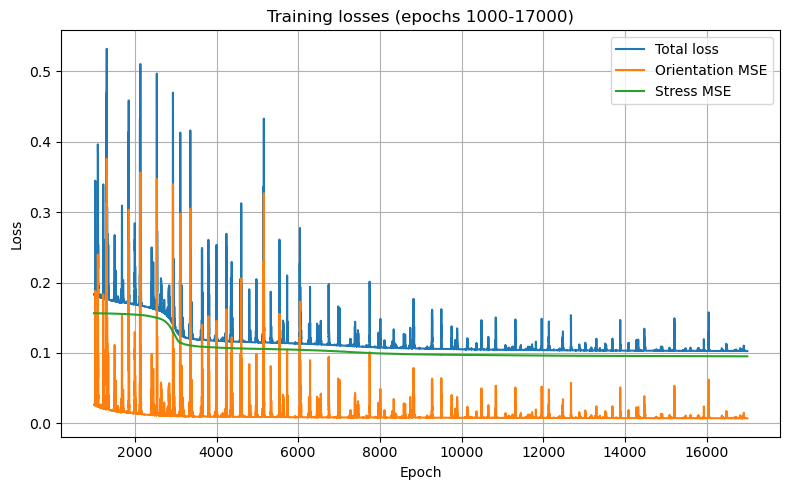

In [20]:
import matplotlib.pyplot as plt

# epochs = range(1, num_epochs + 1)
start_epoch = 1000
end_epoch = 17000

epochs = range(start_epoch, end_epoch)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_history["total"][start_epoch:end_epoch], label="Total loss")
plt.plot(epochs, train_history["ori"][start_epoch:end_epoch], label="Orientation MSE")
plt.plot(epochs, train_history["stress"][start_epoch:end_epoch], label="Stress MSE")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training losses (epochs {start_epoch}-{end_epoch})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [120]:
import torch
import torch.nn.functional as F

def r2_score_torch(y_true: torch.Tensor, y_pred: torch.Tensor, eps: float = 1e-12) -> float:
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + eps)
    return r2.item()

def evaluate_model(model, test_loader, device, quat_eps=1e-8, normalize_true=False):
    """
    normalize_true:
        False (default): assume labels are already unit quats
        True: also normalize q_true for extra safety
    """
    model.eval()

    all_q_pred, all_q_true = [], []
    all_s_pred, all_s_true = [], []

    with torch.no_grad():
        for data, y_true in test_loader:
            data = data.to(device)
            y_true = y_true.to(device)

            y_pred = model(data)

            all_q_pred.append(y_pred[..., 0:4])
            all_q_true.append(y_true[..., 0:4])
            all_s_pred.append(y_pred[..., 4:10])
            all_s_true.append(y_true[..., 4:10])

    q_pred = torch.cat(all_q_pred, dim=0)
    q_true = torch.cat(all_q_true, dim=0)
    s_pred = torch.cat(all_s_pred, dim=0)
    s_true = torch.cat(all_s_true, dim=0)

    # ---- normalize quaternion predictions (and optionally labels) ----
    q_pred = F.normalize(q_pred, p=2, dim=-1, eps=quat_eps)
    if normalize_true:
        q_true = F.normalize(q_true, p=2, dim=-1, eps=quat_eps)

    # ---- metrics ----
    theta = quaternion_misorientation_angle(q_pred, q_true)  # radians
    ori_mse = torch.mean(theta ** 2).item()

    stress_mse = F.mse_loss(s_pred, s_true).item()
    stress_r2  = r2_score_torch(s_true, s_pred)

    results = {
        "ori_mse": ori_mse,
        "stress_mse": stress_mse,
        "stress_r2": stress_r2,
        "theta_mean": theta.mean().item(),
        "theta_rmse": torch.sqrt(torch.mean(theta ** 2)).item(),
    }
    return results

In [121]:
import torch
import torch.nn.functional as F

def print_compare_path_grain_inc(
    model,
    dataset,
    path_idx: int,
    grain_idx: int,
    inc_idx: int,
    device,
    quat_eps=1e-8,
    voigt_names=None,
    average_over_grains=False,
):
    """
    dataset[path_idx] returns one strain path sample.

    Compare predicted vs true quaternion + stress for:
      - a specific grain (grain_idx) at increment (inc_idx), OR
      - the mean over all grains if average_over_grains=True.

    Shapes assumed:
      y_true, y_pred are either:
        [N_grains, T, F]  or [B, N_grains, T, F]
      with F >= 10 and first 10 are [q(4), stress(6)].
    """
    if voigt_names is None:
        voigt_names = ["s11", "s22", "s33", "s12", "s23", "s13"]

    model.eval()
    data, y_true = dataset[path_idx]
    data = data.to(device)
    y_true = y_true.to(device)

    with torch.no_grad():
        y_pred = model(data)

    # Ensure [B,N,T,F]
    if y_true.dim() == 3:  # [N,T,F]
        y_true = y_true.unsqueeze(0)
    if y_pred.dim() == 3:
        y_pred = y_pred.unsqueeze(0)

    # Slice increment
    q_true = y_true[:, :, inc_idx, 0:4]   # [B,N,4]
    q_pred = y_pred[:, :, inc_idx, 0:4]
    s_true = y_true[:, :, inc_idx, 4:10]  # [B,N,6]
    s_pred = y_pred[:, :, inc_idx, 4:10]

    if average_over_grains:
        # mean over grains (nodes)
        q_true_sel = q_true.mean(dim=1)   # [B,4]
        q_pred_sel = q_pred.mean(dim=1)
        s_true_sel = s_true.mean(dim=1)   # [B,6]
        s_pred_sel = s_pred.mean(dim=1)
        label = f"PATH {path_idx} | mean over all grains | inc {inc_idx}"
    else:
        # specific grain
        q_true_sel = q_true[:, grain_idx, :]  # [B,4]
        q_pred_sel = q_pred[:, grain_idx, :]
        s_true_sel = s_true[:, grain_idx, :]  # [B,6]
        s_pred_sel = s_pred[:, grain_idx, :]
        label = f"PATH {path_idx} | grain {grain_idx} | inc {inc_idx}"

    # Normalize quats for comparison/printing
    q_true_unit = F.normalize(q_true_sel, p=2, dim=-1, eps=quat_eps)
    q_pred_unit = F.normalize(q_pred_sel, p=2, dim=-1, eps=quat_eps)

    # Misorientation (your function)
    theta = quaternion_misorientation_angle(q_pred_unit, q_true_unit)  # [B] usually

    # torch-only deg conversion
    pi = torch.acos(torch.zeros(1, device=device)).item() * 2.0
    theta_deg = theta * (180.0 / pi)

    # Take first batch element for printing
    qT = q_true_unit[0].detach().cpu()
    qP = q_pred_unit[0].detach().cpu()
    sT = s_true_sel[0].detach().cpu()
    sP = s_pred_sel[0].detach().cpu()

    print(f"\n=== {label} ===")
    print("q_pred:", [float(f"{v:.6g}") for v in qP.tolist()])
    print("q_true:", [float(f"{v:.6g}") for v in qT.tolist()])
    print(f"misorientation (deg): mean={theta_deg.mean().item():.6f}, max={theta_deg.max().item():.6f}")

    print("\nStress (pred / true / err):")
    for k, name in enumerate(voigt_names):
        p = sP[k].item()
        t = sT[k].item()
        print(f"  {name:>3}:  pred={p: .6f}   true={t: .6f}   err={p-t: .6f}")

    stress_mse = F.mse_loss(sP, sT).item()
    stress_mae = torch.mean(torch.abs(sP - sT)).item()
    print(f"\nstress MSE={stress_mse:.6e}, stress MAE={stress_mae:.6e}")


In [ ]:
checkpoint = torch.load("tgnn_simulation_20000e.pt", map_location=device)
# checkpoint = torch.load("checkpoints/best_checkpoint.pt", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

In [123]:
results = evaluate_model(model, test_loader, device, normalize_true=False)
print(results)

{'ori_mse': 0.0044071124866604805, 'stress_mse': 0.3825973868370056, 'stress_r2': -2.745753049850464, 'theta_mean': 0.0526144802570343, 'theta_rmse': 0.06638608872890472}


In [124]:
path_idx  = 0     # which strain path sample
grain_idx = 18    # which grain/node within that path (0..99)
inc_idx   = 12     # which increment (0..12)

print_compare_path_grain_inc(model, test_loader.dataset, path_idx, grain_idx, 0, device)
print_compare_path_grain_inc(model, test_loader.dataset, path_idx, grain_idx, 1, device)
print_compare_path_grain_inc(model, test_loader.dataset, path_idx, grain_idx, inc_idx, device)

# or compare mean over all grains:
# print_compare_path_grain_inc(model, test_loader.dataset, path_idx, grain_idx, inc_idx, device, average_over_grains=True)


=== PATH 0 | grain 18 | inc 0 ===
q_pred: [0.50793, 0.532883, 0.663666, 0.132629]
q_true: [0.514611, 0.529467, 0.661079, 0.133472]
misorientation (deg): mean=0.913424, max=0.913424

Stress (pred / true / err):
  s11:  pred=-0.074078   true=-0.085591   err= 0.011513
  s22:  pred= 0.045137   true= 0.039132   err= 0.006005
  s33:  pred=-0.196418   true=-0.152549   err=-0.043869
  s12:  pred=-0.002628   true= 0.035866   err=-0.038493
  s23:  pred= 0.000980   true= 0.006883   err=-0.005902
  s13:  pred= 0.014025   true= 0.059618   err=-0.045593

stress MSE=9.480724e-04, stress MAE=2.522944e-02

=== PATH 0 | grain 18 | inc 1 ===
q_pred: [-0.518583, -0.532663, -0.65616, -0.129597]
q_true: [0.512349, 0.529343, 0.662591, 0.135159]
misorientation (deg): mean=1.266694, max=1.266694

Stress (pred / true / err):
  s11:  pred=-0.142942   true= 0.508667   err=-0.651609
  s22:  pred= 0.026505   true= 0.048433   err=-0.021928
  s33:  pred=-0.254036   true= 0.511491   err=-0.765527
  s12:  pred= 0.0207

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch

def get_neighbors(edge_index: torch.Tensor, node_id: int):
    """
    edge_index: torch.LongTensor of shape (2, E)
    Returns a sorted Python list of unique neighbors of node_id.
    Works without NumPy.
    """
    if edge_index.device.type != "cpu":
        ei = edge_index.cpu()
    else:
        ei = edge_index

    src = ei[0]
    dst = ei[1]

    node = torch.tensor(node_id, dtype=src.dtype)

    # neighbors where node_id is source
    n1 = dst[src == node]
    # neighbors where node_id is destination
    n2 = src[dst == node]

    neigh = torch.unique(torch.cat([n1, n2], dim=0))
    neigh = neigh[neigh != node]  # remove self if present

    # sorted list for stable plotting
    neigh, _ = torch.sort(neigh)
    return neigh.tolist()



def plot_grain_and_neighbors_stress(
    all_data,
    edge_index_tensor,
    loadcase_idx,
    grain_id,
    component="sigma11",
    max_neighbors=None,   # e.g., 10 to limit clutter
):
    """
    all_data: (n_loadcases, n_grains, n_incs, n_features)
    edge_index_tensor: (2, E)
    loadcase_idx: int
    grain_id: int
    component: one of ["sigma11","sigma22","sigma33","sigma12","sigma13","sigma23"]
    max_neighbors: if not None, plot only first N neighbors (sorted)
    """

    comp_map = {
        "sigma11": 0, "sigma22": 1, "sigma33": 2,
        "sigma12": 3, "sigma13": 4, "sigma23": 5
    }
    if component not in comp_map:
        raise ValueError(f"component must be one of {list(comp_map.keys())}")

    # --- neighbors ---
    neighbors = get_neighbors(edge_index_tensor, grain_id)
    if max_neighbors is not None:
        neighbors = neighbors[:max_neighbors]

    # --- central grain series ---
    stress9_center = all_data[loadcase_idx, grain_id, :, 22:31]   # (n_incs, 9)
    stress6_center = tensor9_to_voigt6(stress9_center)            # (n_incs, 6)
    y_center = stress6_center[:, comp_map[component]]

    x = np.arange(y_center.shape[0])  # increment index (0..12). Use *10 if you want 0,10,...,120

    fig, ax = plt.subplots(figsize=(10, 6))

    # plot center bold
    ax.plot(x, y_center, linewidth=3, label=f"grain {grain_id} (center)")

    # --- neighbor series ---
    for nb in neighbors:
        stress9_nb = all_data[loadcase_idx, nb, :, 22:31]
        stress6_nb = tensor9_to_voigt6(stress9_nb)
        y_nb = stress6_nb[:, comp_map[component]]
        ax.plot(x, y_nb, alpha=0.7, label=f"grain {nb}")

    ax.set_xlabel("Increment index")
    ax.set_ylabel(component)
    ax.set_title(f"{component}: grain {grain_id} + {len(neighbors)} neighbors (loadcase {loadcase_idx})")
    ax.grid(True)

    # legends can get huge; tweak if needed
    ax.legend(ncol=2, fontsize=8)

    plt.show()
    plt.close(fig)

    return neighbors

loadcase = 4
grain_id = 18

plot_grain_and_neighbors_stress(all_data, edge_index_tensor, loadcase, grain_id, "sigma11")

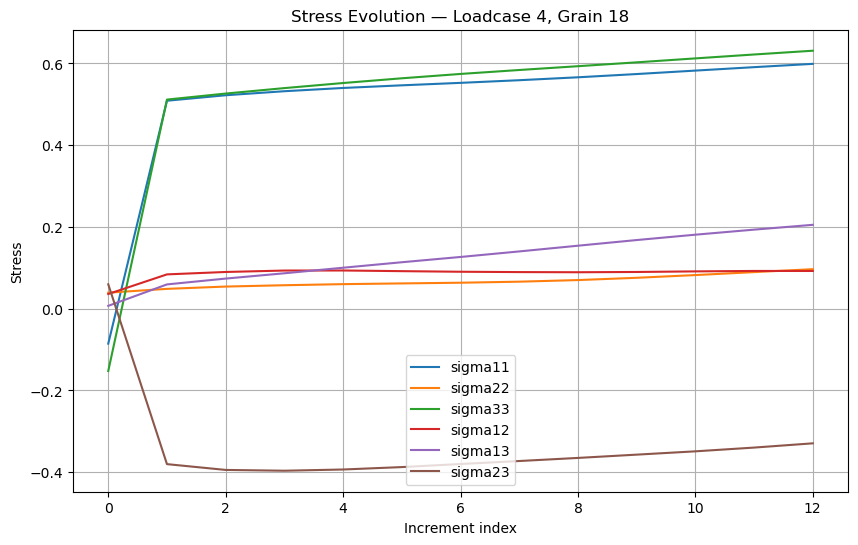

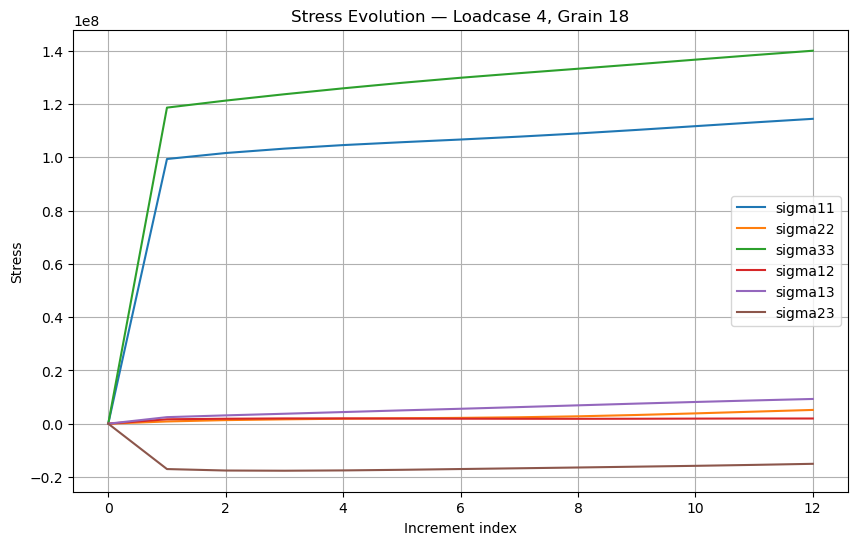

In [130]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

def plot_grain_stress(all_data, loadcase_idx, grain_id):
    """
    all_data: (n_loadcases, n_grains, n_incs, n_features)
    loadcase_idx: int (which strain path / loadcase)
    grain_id: int
    """
    # slice 9 stress components: (n_incs, 9)
    stress9 = all_data[loadcase_idx, grain_id, :, 22:31]

    # convert to Voigt: (n_incs, 6)
    stress = tensor9_to_voigt6(stress9)

    increments = np.arange(stress.shape[0])

    labels = ['sigma11','sigma22','sigma33','sigma12','sigma13','sigma23']

    plt.figure(figsize=(10, 6))
    for i in range(6):
        plt.plot(increments, stress[:, i], label=labels[i])

    plt.xlabel("Increment index")
    plt.ylabel("Stress")
    plt.title(f"Stress Evolution — Loadcase {loadcase_idx}, Grain {grain_id}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # print(stress)

loadcase = 4
grain_id = 18

plot_grain_stress(all_data, loadcase_idx=loadcase, grain_id=grain_id)
plot_grain_stress(all_data_raw, loadcase_idx=loadcase, grain_id=grain_id)

# stress_tensor = all_data[0, 5, :, 22:31]
# print(strain_path[0, 6, 22:31])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_random_grains_stress(
    all_data,
    loadcase_idx,
    component="sigma11",
    n_grains=10,
    seed=0,
):
    """
    Plots one chosen stress component for N random grains on the same graph.

    all_data: (n_loadcases, n_grains, n_incs, n_features)
    loadcase_idx: int
    component: one of ["sigma11","sigma22","sigma33","sigma12","sigma13","sigma23"]
    n_grains: number of random grains to plot
    seed: RNG seed for reproducibility
    """
    comp_map = {
        "sigma11": 0,
        "sigma22": 1,
        "sigma33": 2,
        "sigma12": 3,
        "sigma13": 4,
        "sigma23": 5,
    }
    if component not in comp_map:
        raise ValueError(f"component must be one of {list(comp_map.keys())}")

    rng = np.random.default_rng(seed)
    grain_ids = rng.choice(100, size=n_grains, replace=False)

    fig, ax = plt.subplots(figsize=(10, 6))

    for g in grain_ids:
        stress9 = all_data[loadcase_idx, g, :, 22:31]  # (n_incs, 9)
        stress6 = tensor9_to_voigt6(stress9)           # (n_incs, 6)
        y = stress6[:, comp_map[component]]
        x = np.arange(y.shape[0])  # increments index
        ax.plot(x, y, label=f"grain {g}", alpha=0.8)

    ax.set_xlabel("Increment index")
    ax.set_ylabel(component)
    ax.set_title(f"{component} — {n_grains} random grains (loadcase {loadcase_idx})")
    ax.grid(True)
    ax.legend(ncol=2, fontsize=8)

    plt.show()
    plt.close(fig)

    return grain_ids  # handy to know which grains were plotted

plot_random_grains_stress(all_data, 0, "sigma13", 10, 6)